# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы: 
- Вы **сами** решаете, что <font color="#cb9255">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [26]:
import pandas as pd

dota_chat = pd.read_csv("game_chat.csv")
dota_chat[dota_chat.notna()["radiant_chat"] & dota_chat.notna()["dire_chat"]]

,match_id,radiant_chat,dire_chat
0,235435,потренируйся с ботами????,саппортам | U LAGGING BRAH | stack..... | шлюх
19,422105,reaaaady,经济碾压
42,83915,打得可以 | 打人机去,DC | HG
65,308048,团战乱杀,实力差距 | 一直送
86,213927,ТИИПНИТЕ И МЫ ГГ ПРОПИШЕМ,dagger
...,...,...,...
700530,348911,b,hi.....
700568,378812,safe,HP.... | спасибо | папича
700665,514749,ИЗИ | ggwp,yawa na tayo dyan mga bes?.
700701,496897,0 | bb,дальше | ВИНСТРИК


Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст — вопрос неоднозначный. В целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <br>
<font color="#cb9255">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать-не включать, выкинуть-оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:** Спасибо доте, что в нее играют лишь русские и китайцы(как я прочитал) поэтому на часть иностранных сообщенией можно забить(их будет мало и в основном это будет какой-то сленг по типу гг или еще чего), а так что касается общей картины, мне кажется, что надо в основном смотреть на эмоциональность сообщений, проигравший игрок не будет рад, поэтому мы оставим: повторы символов(разница между гол и гооооооооооооооол велика как по мне, и вторая фраза описывает радость), знаки препинания уберем пожалуй, кто во время игры следит за пунктуацией, стоп слова тоже уберем, они не несут каких либо эмоций или смысла, нижний регистр сомнительно, я не вижу причин убирать его, но может в дальнейшем уберу 

</div>

In [ ]:
import re
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from pymystem3 import Mystem

mystem = Mystem()

#пробовал с nltk у меня считало 4 часа, поэтому я лучше буду пользоваться регулярками 
# то же самое с стоп-словами, в nltk очень большая бд, и на каждой проверять не хочется, так что я сделаю свою
# по итогу после всех этих рассуждений я ждал вместо 4 часов 3...
stopwords = {"на", "в","за","the","for","in","at","без","как","вас","ты", "я"}
def preprocessing(text):
    text = str(text).replace("|", " ")
    text = re.sub(r"[^a-zа-яё\s]", " ", text) 
    tokens = re.findall(r"[a-zа-яё]+", text, re.I)
    tokens = [t for t in tokens if len(t) > 1 and t.lower() not in stopwords]
    text_for_lemm = " ".join(tokens)
    # lemmas = mystem.lemmatize(text_for_lemm)
    # result = []
    # for l in lemmas:
    #     if l.strip():
    #         result.append(l.strip())
    return "".join(text_for_lemm)

print(preprocessing("Ляяя, ваша мама такая красивая, ну вылитый пудж)))0 in a at "))

яяя ваша мама такая красивая ну вылитый пудж


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#cb9255">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#cb9255">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#cb9255">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [28]:
x = sp.load_npz('X_train.npz')  # фичи из base
y = sp.load_npz('X_val.npz')

X_train = pd.DataFrame.sparse.from_spmatrix(x)
X_val = pd.DataFrame.sparse.from_spmatrix(y)
y_train = pd.read_csv("y_train.csv")
y_val = pd.read_csv("y_val.csv")


In [29]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0


In [30]:

from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
from scipy.sparse import csr_array, hstack



dota_chat = dota_chat.dropna(subset=["radiant_chat", "dire_chat"]).copy()
dota_chat["radiant_clean"] = dota_chat["radiant_chat"].apply(preprocessing)
dota_chat["dire_clean"]   = dota_chat["dire_chat"].apply(preprocessing)


chat_train = dota_chat.set_index("match_id").reindex(y_train["match_id"])
chat_val   = dota_chat.set_index("match_id").reindex(y_val["match_id"])

# не стал шаманить с гиперпараметрами
vec_rad = TfidfVectorizer(min_df=5, max_df=0.5)
vec_dir = TfidfVectorizer(min_df=5, max_df=0.5)

X_rad_train = vec_rad.fit_transform(chat_train["radiant_clean"].fillna(""))
X_rad_val   = vec_rad.transform(chat_val["radiant_clean"].fillna(""))

X_dir_train = vec_dir.fit_transform(chat_train["dire_clean"].fillna(""))
X_dir_val   = vec_dir.transform(chat_val["dire_clean"].fillna(""))

X_chat_train = sp.hstack([X_rad_train, X_dir_train])
X_chat_val   = sp.hstack([X_rad_val, X_dir_val])

X_train = hstack([x, X_chat_train])
X_val   = hstack([y, X_chat_val])


model = LogisticRegression(C=0.7, solver="lbfgs", max_iter=1500)
model.fit(X_train, y_train.iloc[:, 1])
y_pred = model.predict_proba(X_val)[:, 1]
print()
print()
print("Итоговый Gini:", gini(y_val.iloc[:, 1], y_pred))







Итоговый Gini: 0.29167404980533296


c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
#возвращаем в дата фрейм
X_train = pd.DataFrame.sparse.from_spmatrix(X_train)
X_val = pd.DataFrame.sparse.from_spmatrix(X_val)

In [32]:
X_train = X_train.reset_index()
X_val= X_val.reset_index()
X_train.columns = X_train.columns.astype(str)
X_val.columns = X_val.columns.astype(str) 
X_train #мама... какие 1000 признаков

,index,0,1,2,3,4,5,6,7,8,...,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142
0,0,-1.0,-1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,-1.0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,-1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512028,512028,0,0,1.0,0,0,1.0,0,0,-1.0,...,0,0,0,0,0,0,0,0,0,0
512029,512029,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
512030,512030,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
512031,512031,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

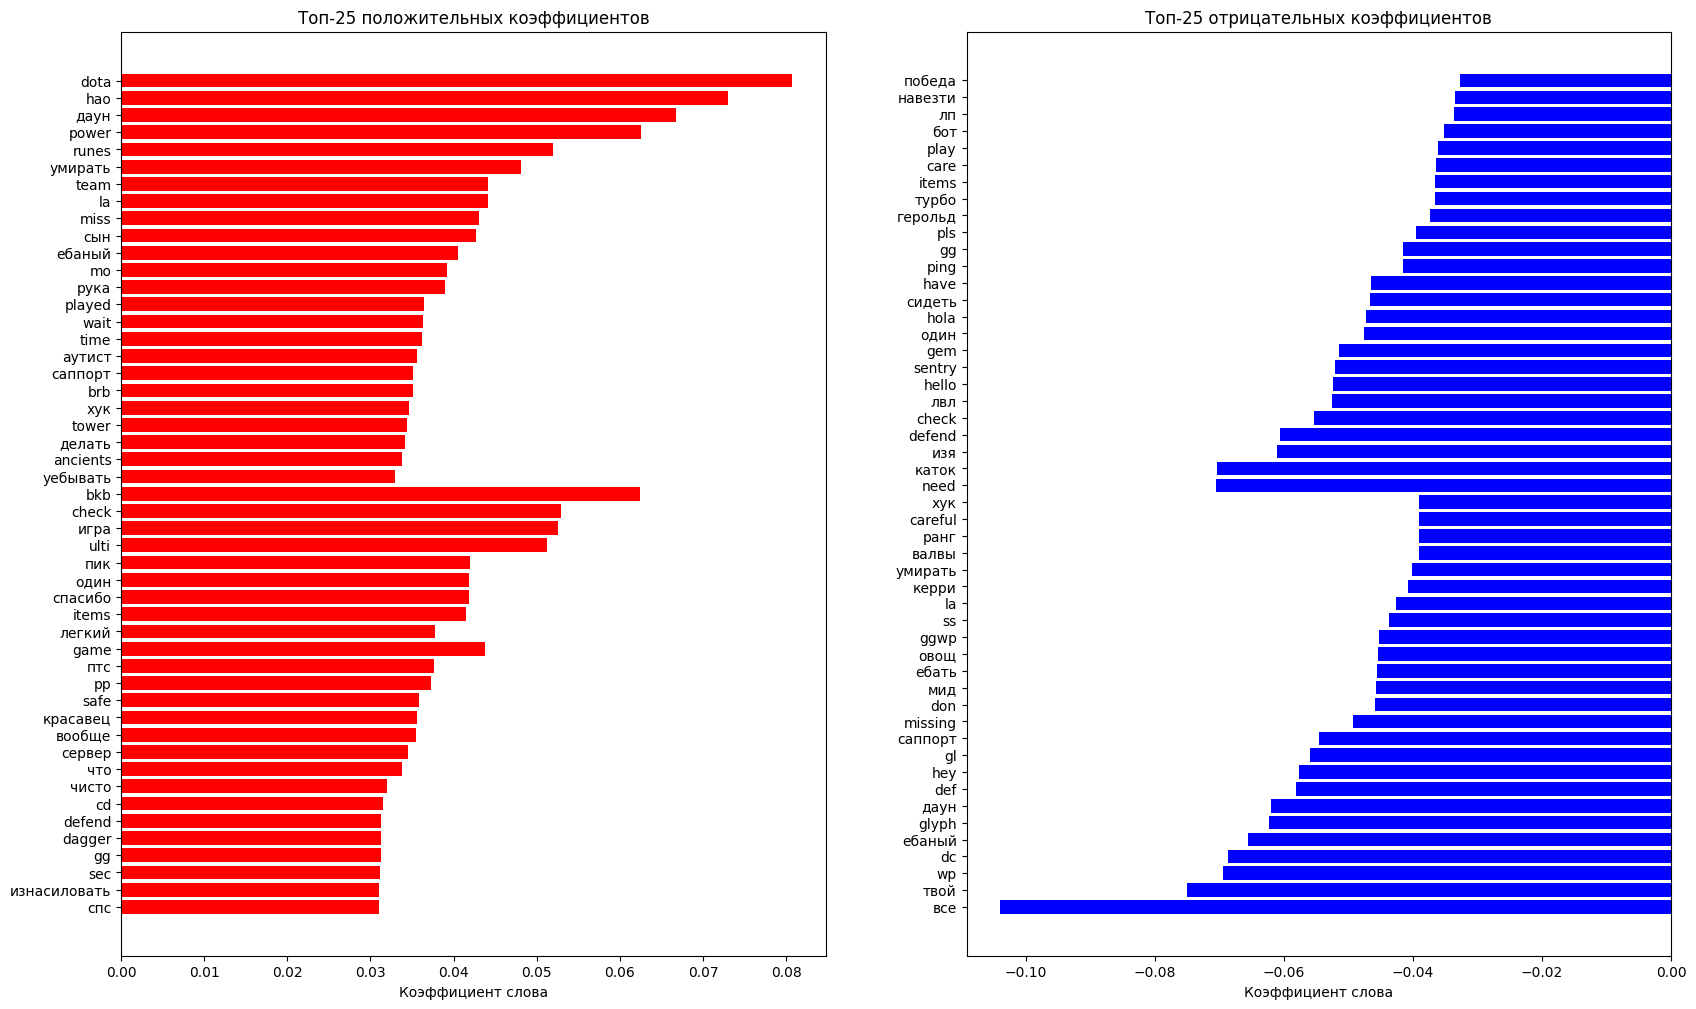

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Получаем коэффициенты
coef = model.coef_[0]
n_base = x.shape[1]
n_rad = X_rad_train.shape[1]
n_dir = X_dir_train.shape[1]

coef_rad = coef[n_base : n_base + n_rad]
coef_dir = coef[n_base + n_rad : n_base + n_rad + n_dir]

names_rad = vec_rad.get_feature_names_out()
names_dir = vec_dir.get_feature_names_out()

# Топ 25 положительных для обоих команд
idx_pos_rad = np.argsort(coef_rad)[-25:]
idx_pos_dir = np.argsort(coef_dir)[-25:]

pos_data = []
for i in idx_pos_rad:
    pos_data.append({'feature': names_rad[i], 'coefficient': coef_rad[i], 'type': 'radiant'})

for i in idx_pos_dir:
    pos_data.append({'feature': names_dir[i], 'coefficient': coef_dir[i], 'type': 'dire'})

pos_df = pd.DataFrame(pos_data)


# Топ 25 отрицательных для обоих команд
idx_neg_rad = np.argsort(coef_rad)[:25]
idx_neg_dir = np.argsort(coef_dir)[:25]

neg_data = []
for i in idx_neg_rad:
    neg_data.append({'feature': names_rad[i], 'coefficient': coef_rad[i], 'type': 'radiant'})
for i in idx_neg_dir:
    neg_data.append({'feature': names_dir[i], 'coefficient': coef_dir[i], 'type': 'dire'})

neg_df = pd.DataFrame(neg_data)


fig, axes = plt.subplots(1, 2, figsize=(20, 12))


# График для положительных признаков
bars1 = axes[0].barh(pos_df['feature'], pos_df['coefficient'], color="red")
axes[0].set_xlabel('Коэффициент слова')
axes[0].set_title('Топ-25 положительных коэффициентов')
axes[0].tick_params(axis='y', labelsize=10)

bars2 = axes[1].barh(neg_df['feature'], neg_df['coefficient'], color="blue")
axes[1].set_xlabel('Коэффициент слова')
axes[1].set_title('Топ-25 отрицательных коэффициентов')
axes[1].tick_params(axis='y', labelsize=10)


# заметь все слова лемантизированы, я успел состариться пока ждал этого..

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:** смущает такое большое количество признаков, да и не сказать, что слова в чате этоо не шумный признак, скорее это хороший признак в совокупности с другим, но никак самостояткльный

</div>

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

,match_id,radiant_gold_adv,radiant_exp_adv
0,526846,[ 0 159 452 1904 2100 3290 3290 3290 3290 ...,[ 0 68 658 1397 1435 2118 2118 1923 1923 ...
1,511496,[ 0 -151 -141 12 -165 -151 -151 4 377 ...,[ 0 1 -136 243 -270 -8 -8 -169 -169 ...
5,15301,[ 0 -248 -527 -1054 -1387 -1808 -1808 -16...,[ 0 -252 -332 -863 -765 -1352 -1352 -13...
8,578050,[ 0 -472 -656 -686 -626 -1706 -1706 -17...,[ 0 -186 -453 -410 -471 -1207 -1207 -13...
12,533238,[ 0 23 69 -508 -433 17 17 17 17 ...,[ 0 -202 -398 -1185 -861 -201 -201 1...
...,...,...,...
767804,585277,[ 0 397 875 834 865 1141 1141 12...,[ 0 73 -189 -38 -603 -727 -727 -823 -524 ...
767814,519943,[ 0 495 781 1203 1549 1811 1811 21...,[ 0 217 480 587 1048 752 752 7...
767815,501459,[ 0 589 151 821 955 546 546 682 373 ...,[ 0 355 158 627 710 555 555 438 197 ...
767817,602640,[ 0 66 -5 -4 286 457 457 2...,[ 0 -207 -558 -807 -686 -917 -917 -9...


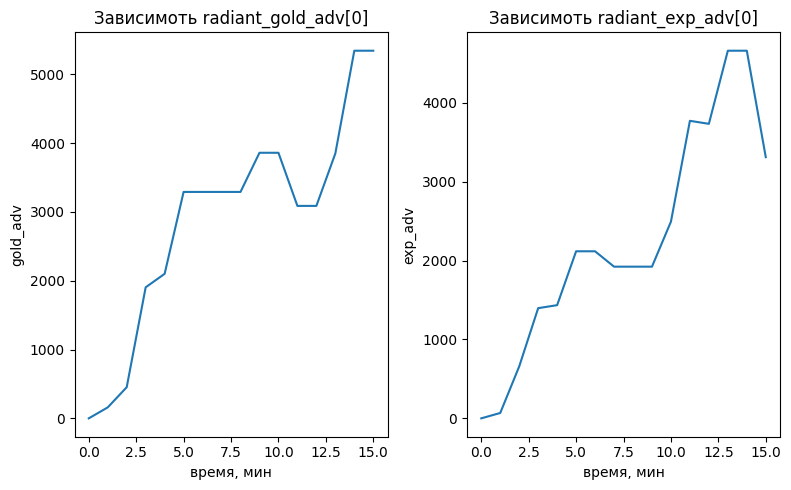

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def f(x, str):
    if x!="[]":
        new_x = list(map(int, x[1:-1].split()))
        if str == "max":
            return np.max(new_x)
        if str == "med":
            return np.median(new_x)
        if str == "var":
            return np.var(new_x)
        if str == "q75":
            return np.percentile(new_x, 75)
        if str == "mean":
            return np.mean(new_x)
    return np.nan


dota_adv = pd.read_csv("dota_adv.csv")
dota_adv.drop(dota_adv[(dota_adv["radiant_gold_adv"] == "[]") & (dota_adv["radiant_exp_adv"] == "[]")].index,inplace=True)

gold = list(map(int,dota_adv.loc[0,"radiant_gold_adv"][1:-1].split()))
exp = list(map(int,dota_adv.loc[0,"radiant_exp_adv"][1:-1].split()))
fig, ax = plt.subplots(1,2,figsize=(8,5))
ax[0].plot(list(range(0,16)),gold)
ax[0].set_title("Зависимоть radiant_gold_adv[0]")
ax[0].set_xlabel("время, мин")
ax[0].set_ylabel("gold_adv")

ax[1].plot(list(range(0,16)),exp)
ax[1].set_title("Зависимоть radiant_exp_adv[0]")
ax[1].set_xlabel("время, мин")
ax[1].set_ylabel("exp_adv")
plt.tight_layout()  

dota_adv

In [112]:
# dota_adv["std_gold"] = dota_adv["radiant_gold_adv"].apply(lambda x: f(x, "std"))
dota_adv["mean_gold"] = dota_adv["radiant_gold_adv"].apply(lambda x: f(x, "mean"))
dota_adv["max_gold"] = dota_adv["radiant_gold_adv"].apply(lambda x: f(x, "max"))
dota_adv["med_gold"] = dota_adv["radiant_gold_adv"].apply(lambda x: f(x, "med"))
# dota_adv["var_gold"] = dota_adv["radiant_gold_adv"].apply(lambda x: f(x, "var"))
dota_adv["q75_gold"] = dota_adv["radiant_gold_adv"].apply(lambda x: f(x, "q75"))



# dota_adv["std_exp"] = dota_adv["radiant_exp_adv"].apply(lambda x: f(x, "std"))
dota_adv["mean_exp"] = dota_adv["radiant_exp_adv"].apply(lambda x: f(x, "mean"))
dota_adv["max_exp"] = dota_adv["radiant_exp_adv"].apply(lambda x: f(x, "max"))
dota_adv["med_exp"] = dota_adv["radiant_exp_adv"].apply(lambda x: f(x, "med"))
# dota_adv["var_exp"] = dota_adv["radiant_exp_adv"].apply(lambda x: f(x, "var"))
dota_adv["q75_exp"] = dota_adv["radiant_exp_adv"].apply(lambda x: f(x, "q75"))


dota_adv = dota_adv.dropna(subset=["q75_gold", "q75_exp","mean_exp","max_exp","med_exp","mean_gold","max_gold","med_gold"])




X_train = pd.merge(
    X_train,
    dota_adv,
    left_on='index',
    right_on='match_id',
    how='left'
)

X_val = pd.merge(
    X_val,
    dota_adv,
    left_on='index',
    right_on='match_id',
    how='left'
)

In [113]:
# # Заменяем наны на медиану
X_train.loc[X_train["mean_gold"].isna(), "mean_gold"] = X_train["mean_gold"].median()
X_train.loc[X_train["max_gold"].isna(), "max_gold"] = X_train["max_gold"].median()
X_train.loc[X_train["med_gold"].isna(), "med_gold"] = X_train["med_gold"].median()
# X_train.loc[X_train["var_gold"].isna(), "var_gold"] = X_train["var_gold"].median()
X_train.loc[X_train["q75_gold"].isna(), "q75_gold"] = X_train["q75_gold"].median()

X_train.loc[X_train["mean_exp"].isna(), "mean_exp"] = X_train["mean_exp"].median()
X_train.loc[X_train["max_exp"].isna(), "max_exp"] = X_train["max_exp"].median()
X_train.loc[X_train["med_exp"].isna(), "med_exp"] = X_train["med_exp"].median()
# X_train.loc[X_train["var_exp"].isna(), "var_exp"] = X_train["var_exp"].median()
X_train.loc[X_train["q75_exp"].isna(), "q75_exp"] = X_train["q75_exp"].median()

X_val.loc[X_val["mean_gold"].isna(), "mean_gold"] = X_val["mean_gold"].median()
X_val.loc[X_val["max_gold"].isna(), "max_gold"] = X_val["max_gold"].median()
X_val.loc[X_val["med_gold"].isna(), "med_gold"] = X_val["med_gold"].median()
# X_val.loc[X_val["var_gold"].isna(), "var_gold"] = X_val["var_gold"].median()
X_val.loc[X_val["q75_gold"].isna(), "q75_gold"] = X_val["q75_gold"].median()

X_val.loc[X_val["mean_exp"].isna(), "mean_exp"] = X_val["mean_exp"].median()
X_val.loc[X_val["max_exp"].isna(), "max_exp"] = X_val["max_exp"].median()
X_val.loc[X_val["med_exp"].isna(), "med_exp"] = X_val["med_exp"].median()
# X_val.loc[X_val["var_exp"].isna(), "var_exp"] = X_val["var_exp"].median()
X_val.loc[X_val["q75_exp"].isna(), "q75_exp"] = X_val["q75_exp"].median()




X_train["q75_exp_radiant"] = X_train["q75_exp"].clip(lower=0)
X_train["q75_exp_dire"]    = (-X_train["q75_exp"].clip(upper=0))

X_val["q75_exp_radiant"] = X_val["q75_exp"].clip(lower=0)
X_val["q75_exp_dire"]    = (-X_val["q75_exp"].clip(upper=0))



X_train.drop(columns=["radiant_gold_adv", "radiant_exp_adv", "match_id","q75_exp",], inplace=True)
X_val.drop(columns=["radiant_gold_adv", "radiant_exp_adv", "match_id","q75_exp"], inplace=True)

In [114]:
X_train

,index,0,1,2,3,4,5,6,7,8,...,1142,mean_gold,max_gold,med_gold,q75_gold,mean_exp,max_exp,med_exp,q75_exp_radiant,q75_exp_dire
0,0,-1.0,-1.0,0,0,0,0,0,0,0,...,0,201.3125,1582.0,56.0,521.50,165.8750,1506.0,29.5,465.0,-0.00
1,1,0,0,0,0,0,0,0,0,0,...,0,201.3125,1582.0,56.0,521.50,165.8750,1506.0,29.5,465.0,-0.00
2,2,0,0,0,0,0,0,0,-1.0,0,...,0,201.3125,1582.0,56.0,521.50,165.8750,1506.0,29.5,465.0,-0.00
3,3,0,0,0,0,0,0,0,0,0,...,0,201.3125,1582.0,56.0,521.50,165.8750,1506.0,29.5,465.0,-0.00
4,4,0,0,0,0,0,-1.0,0,0,0,...,0,201.3125,1582.0,56.0,521.50,165.8750,1506.0,29.5,465.0,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512028,512028,0,0,1.0,0,0,1.0,0,0,-1.0,...,0,-868.6875,61.0,-810.5,-586.50,-1861.2500,0.0,-1635.5,0.0,1029.25
512029,512029,0,0,0,0,0,0,0,0,0,...,0,32.3750,1116.0,95.5,327.50,-1819.8750,22.0,-1428.0,0.0,283.00
512030,512030,0,0,0,0,0,0,0,0,0,...,0,891.0625,6183.0,50.5,760.50,-475.1250,468.0,-405.0,0.0,125.25
512031,512031,0,0,0,0,0,0,0,0,0,...,0,-1895.8750,0.0,-2059.0,-958.00,-1211.1875,0.0,-1546.0,0.0,275.00


Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:** если эти числа чем лучше, тем выше вероятность победить, то возьмем максимум и что-то вроде того(выбрал из 4 только одну, так как на боьлшем числе признаков он переобучается) 

</div>

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

num_cols = ["mean_gold", "max_gold", "med_gold", "q75_gold", "mean_exp", "max_exp", "med_exp", "q75_exp_radiant", "q75_exp_dire"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

model = LogisticRegression(C=48.8944801765785, solver="lbfgs",max_iter = 3000)
model.fit(X_train, y_train.iloc[:, 1])
y_pred = model.predict_proba(X_val)[:,1]

print(gini(y_val.iloc[:,1],y_pred))

c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


0.27416953748803796


По сравнению с baseline улучшения есть! 0.27416953748803796 вместо 0.2726

#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее — она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:** тренд полезен потому что он как бы к статическим признакам добавляет динамику 

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [116]:
from typing import Iterable
import numpy as np

class TrendTransformer:

    def __init__(self, columns: Iterable[str], method: str):
        
        self.columns = list(columns)
        self.method = method

    def fit(self, x,y=None):
        
        if x!="[]":
            return np.array(list(map(int, x[1:-1].split())))
        else:
            return np.nan()

    def slope(self, arr: np.ndarray) -> float:
        if arr.size == 0:
            return np.nan

        if self.method == "delta":
            return float(arr[-1] - arr[0])
            
        if self.method == "OLS":
            t = np.arange(arr.size, dtype=float)
            a, b = np.polyfit(t, arr, 1)
            return float(a)
        return float(arr[-1] - arr[0])

    def transform(self, X, y=None):
        X_new = X.copy()
        for col in self.columns:
            new_col = col + "_slope_new"
            X_new[new_col] = X_new[col].apply(lambda v: self.slope(self.fit(v)))
        return X_new

In [117]:
X_train

,index,0,1,2,3,4,5,6,7,8,...,1142,mean_gold,max_gold,med_gold,q75_gold,mean_exp,max_exp,med_exp,q75_exp_radiant,q75_exp_dire
0,0,-1.0,-1.0,0,0,0,0,0,0,0,...,0,-0.001404,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686
1,1,0,0,0,0,0,0,0,0,0,...,0,-0.001404,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686
2,2,0,0,0,0,0,0,0,-1.0,0,...,0,-0.001404,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686
3,3,0,0,0,0,0,0,0,0,0,...,0,-0.001404,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686
4,4,0,0,0,0,0,-1.0,0,0,0,...,0,-0.001404,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512028,512028,0,0,1.0,0,0,1.0,0,0,-1.0,...,0,-0.003421,-0.002384,-1.465959,-0.002086,-3.830327,-1.562703,-3.759194,-1.029437,6.231189
512029,512029,0,0,0,0,0,0,0,0,0,...,0,-0.001722,-0.001763,0.041967,-0.001547,-3.752208,-1.541804,-3.293185,-1.029437,1.579407
512030,512030,0,0,0,0,0,0,0,0,0,...,0,-0.000103,0.001224,-0.032930,-0.001292,-1.213230,-1.118120,-0.995706,-1.029437,0.596065
512031,512031,0,0,0,0,0,0,0,0,0,...,0,-0.005359,-0.002420,-3.543934,-0.002305,-2.602965,-1.562703,-3.558192,-1.029437,1.529539


Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [118]:
tt = TrendTransformer(columns=["radiant_gold_adv", "radiant_exp_adv"], method="OLS")
dota_adv_trend = tt.transform(dota_adv)
dota_adv_trend.drop(columns=["q75_gold","q75_exp","radiant_gold_adv","radiant_exp_adv","mean_gold","max_gold","med_gold","mean_exp","max_exp","med_exp"], inplace=True)

X_train = pd.merge(
    X_train,
    dota_adv_trend,
    left_on='index',
    right_on='match_id',
    how='left'
)
X_val = pd.merge(
    X_val,
    dota_adv_trend,
    left_on='index',
    right_on='match_id',
    how='left'
)

X_train.loc[X_train["radiant_gold_adv_slope_new"].isna(), "radiant_gold_adv_slope_new"] = X_train["radiant_gold_adv_slope_new"].median()
X_train.loc[X_train["radiant_exp_adv_slope_new"].isna(), "radiant_exp_adv_slope_new"] = X_train["radiant_exp_adv_slope_new"].median()
X_val.loc[X_val["radiant_gold_adv_slope_new"].isna(), "radiant_gold_adv_slope_new"] = X_val["radiant_gold_adv_slope_new"].median()
X_val.loc[X_val["radiant_exp_adv_slope_new"].isna(), "radiant_exp_adv_slope_new"] = X_val["radiant_exp_adv_slope_new"].median()

X_train.drop(columns=["match_id"], inplace=True)
X_val.drop(columns=["match_id"], inplace=True)

In [119]:
X_train

,index,0,1,2,3,4,5,6,7,8,...,max_gold,med_gold,q75_gold,mean_exp,max_exp,med_exp,q75_exp_radiant,q75_exp_dire,radiant_gold_adv_slope_new,radiant_exp_adv_slope_new
0,0,-1.0,-1.0,0,0,0,0,0,0,0,...,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686,48.982353,47.360294
1,1,0,0,0,0,0,0,0,0,0,...,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686,48.982353,47.360294
2,2,0,0,0,0,0,0,0,-1.0,0,...,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686,48.982353,47.360294
3,3,0,0,0,0,0,0,0,0,0,...,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686,48.982353,47.360294
4,4,0,0,0,0,0,-1.0,0,0,0,...,-0.001488,-0.023776,-0.001433,-0.002978,-0.132057,-0.019895,-0.160787,-0.184686,48.982353,47.360294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512028,512028,0,0,1.0,0,0,1.0,0,0,-1.0,...,-0.002384,-1.465959,-0.002086,-3.830327,-1.562703,-3.759194,-1.029437,6.231189,-96.469118,-201.623529
512029,512029,0,0,0,0,0,0,0,0,0,...,-0.001763,0.041967,-0.001547,-3.752208,-1.541804,-3.293185,-1.029437,1.579407,7.338235,-324.211765
512030,512030,0,0,0,0,0,0,0,0,0,...,0.001224,-0.032930,-0.001292,-1.213230,-1.118120,-0.995706,-1.029437,0.596065,295.589706,-25.476471
512031,512031,0,0,0,0,0,0,0,0,0,...,-0.002420,-3.543934,-0.002305,-2.602965,-1.562703,-3.558192,-1.029437,1.529539,-206.144118,-62.557353


In [120]:
model = LogisticRegression(C=48.8944801765785, solver="lbfgs",max_iter = 3000)
model.fit(X_train, y_train.iloc[:, 1])
y_pred = model.predict_proba(X_val)[:,1]

print(gini(y_val.iloc[:,1],y_pred))

c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns 

0.27287111209798587


Улучшения тоже есть, но не существенные ;) 0.27287111209798587 вместо 0.2726

#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на <font color="cb9255">**МОП**</font>? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

In [121]:
import numpy as np
import pandas as pd

import pandas as pd

matches_df_train = pd.read_csv("matches_df_train.csv")

def f_max(x):
    if x == "[]":
        return np.nan
    s = x.strip()[1:-1]
    return max(map(int, s.split()))

dota_adv["max_gold"] = dota_adv["radiant_gold_adv"].apply(f_max)
dota_adv["max_exp"]  = dota_adv["radiant_exp_adv"].apply(f_max)

dota_adv["gold_bin"] = pd.qcut(dota_adv["max_gold"], q=4, labels=False, duplicates="drop")
dota_adv["exp_bin"]  = pd.qcut(dota_adv["max_exp"],  q=4, labels=False, duplicates="drop")

adv_target = pd.merge(
    dota_adv[["match_id", "gold_bin", "exp_bin"]],
    matches_df_train[["match_id", "radiant_win"]],
    on="match_id",
    how="left"
)

gold_bin_stats = adv_target.groupby("gold_bin")["radiant_win"].agg(["mean", "count"])
exp_bin_stats  = adv_target.groupby("exp_bin")["radiant_win"].agg(["mean", "count"])

print("Gold bins:")
display(gold_bin_stats)

print("\nExp bins:")
display(exp_bin_stats)

Gold bins:


,mean,count
gold_bin,,
0,0.28345,49970
1,0.441663,49703
2,0.584091,49405
3,0.732661,49499



Exp bins:


,mean,count
exp_bin,,
0,0.348541,50063
1,0.479281,49762
2,0.563691,49348
3,0.650211,49404


### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

In [122]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- для каждой модели хранятся метрики на валидации

Сделайте и продемонстрируйте

In [123]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`. 

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [124]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [125]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#cb9255">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#cb9255">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

In [126]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.